# Formel 1 Analys
Jag kommer analysera Formel 1 data från Kaggle för att undersöka hur viktiga är startpositionerna egentligen för ett vinnande lopp.

Datasetet innehåller historiska resultat mellan år 1950 - 2024 som innehåller flera olika .csv filer.

I mitt fall kommer jag använda mig utav "results.csv" filen, där varje rad respresenterar en förares resultat i varje lopp

Populationen som analyseras är alla förares lopp resultat som finns i datasetet.

Syftet med analysen är att besvara följande huvudfråga:

**Hur påverkar startpositionen resultatet i Formel 1?**

För att besvara huvudfrågan undersöker jag tre delpåstående:

1. Bättre startpositioner ger fler poäng i genomsnitt genom historien
2. Bättre startposition ger större chans till första plats
3. Startpositionen har stor betydelse

In [193]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Läser in från .csv
results = pd.read_csv("data/results.csv")

## Inläsning och mekanisk inspektion
Har laddat ned 1 fil från Kaggle: "results.csv". Här finns den centrala racingdatan.

Det som kommer användas för den mekaniska inspektionen är:

.head() - första 5 raderna för i DataFrame (kolumner,datatyper)

.shape - se datasetets storlek

.info() - 

.describe() - 

### Analys med ".head()"
För att få en snabb överblick av datasetet använder jag ".head()", som visar dem 5 första raderna i en DataFrame. Här kan jag kolla igenom vilka kolumner som finns och kontrollera att inläsningen gick rätt till. 

In [195]:
results.head()


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


### Dataset storlek med ".shape"
".shape" retunerar ett x antal rader och kolumner.  


In [198]:
results.shape

(26759, 18)

### Datatyper och saknade värden med ".info()"
För att få en översikt av strukturen används ".info()".
Metoden visar följande :
- Kolumner 
- Datatyper
- Minne 

Resultatet visar 26 759 rader med 18 kolumner. Det finns även inga sakande värden, vilket leder till att jag inte behöver hantera tomma värden. Filen tar 3.7 MB i minnet. Det finns 3 olika datyper: float, int och str.



In [199]:
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         26759 non-null  int64  
 1   raceId           26759 non-null  int64  
 2   driverId         26759 non-null  int64  
 3   constructorId    26759 non-null  int64  
 4   number           26759 non-null  str    
 5   grid             26759 non-null  int64  
 6   position         26759 non-null  str    
 7   positionText     26759 non-null  str    
 8   positionOrder    26759 non-null  int64  
 9   points           26759 non-null  float64
 10  laps             26759 non-null  int64  
 11  time             26759 non-null  str    
 12  milliseconds     26759 non-null  str    
 13  fastestLap       26759 non-null  str    
 14  rank             26759 non-null  str    
 15  fastestLapTime   26759 non-null  str    
 16  fastestLapSpeed  26759 non-null  str    
 17  statusId         26759 

### Sammanfattning med ".describe()"
Metoden ".describe()" ger en snabb överblick av de numeriska kolumnerna. Visar bland annat: antal värden, medelvärde och min/max. 

In [200]:
results.describe()

,resultId,raceId,driverId,constructorId,grid,positionOrder,points,laps,statusId
count,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000
mean,13380.977391,551.687283,278.673530,50.180537,11.134796,12.794051,1.987632,46.301768,17.224971
std,7726.134642,313.265036,282.703039,61.551498,7.202860,7.665951,4.351209,29.496557,26.026104
min,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,6690.500000,300.000000,57.000000,6.000000,5.000000,6.000000,0.000000,23.000000,1.000000
50%,13380.000000,531.000000,172.000000,25.000000,11.000000,12.000000,0.000000,53.000000,10.000000
75%,20069.500000,811.000000,399.500000,63.000000,17.000000,18.000000,2.000000,66.000000,14.000000
max,26764.000000,1144.000000,862.000000,215.000000,34.000000,39.000000,50.000000,200.000000,141.000000


## Datatvätt
Innan jag börjar med visualisering och analys behöver jag granska och eventuellt tvätta data. Det kan inehålla dolda saknade värden, fel datatyper och kolumner som kanske inte är relevanta för analys. Jag kommer inte tvätta om det inte behövs, kommer fokusera på dem kolumnerna som används i mina visualiseringar.

Mina kolumner jag kommer fokusera på är grid, positionOrder och points. Där kontrollerar jag datatyper, dubletter, saknade värden och dolda saknade värden. 

In [201]:
# Tar fram olika datatyper som används
results.dtypes  

resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number                 str
grid                 int64
position               str
positionText           str
positionOrder        int64
points             float64
laps                 int64
time                   str
milliseconds           str
fastestLap             str
rank                   str
fastestLapTime         str
fastestLapSpeed        str
statusId             int64
dtype: object

In [202]:
# Markerar dubletter som True och räknar antal True värden som finns
results.duplicated().sum()

np.int64(0)

In [203]:
# Kontrollerar saknade värden
# True där värdet saknas sedan räkna hur många sakande värden varje kolumn har
results.isnull().sum() 


resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
dtype: int64

In [ ]:
# Dubletter kan komma i form av textvärde
# Räknar "\N" som textvärde.
(results == r"\N").sum()

resultId               0
raceId                 0
driverId               0
constructorId          0
number                 6
grid                   0
position           10953
positionText           0
positionOrder          0
points                 0
laps                   0
time               19079
milliseconds       19079
fastestLap         18507
rank               18249
fastestLapTime     18507
fastestLapSpeed    18507
statusId               0
dtype: int64

In [ ]:
# Ersätter textvärde med riktiga saknade värden
results = results.replace(r"\N", np.nan)

## Visualisering 1: Bättre startpositioner ger fler poäng i genomsnitt genom historien

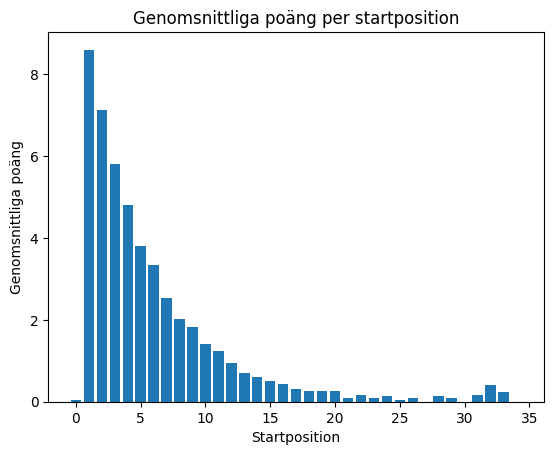

In [ ]:
# Grupperar resultat efter startposition och tar genomsnitten
average_points = results.groupby("grid")["points"].mean()

# Stapeldiagram
plt.bar(average_points.index, average_points.values)

# Titel och axelrubriker
plt.title("Genomsnittliga poäng per startposition")
plt.xlabel("Startposition")
plt.ylabel("Genomsnittliga poäng")

# Visar grafen
plt.show()

In [ ]:
# Bevisar skillnaden med rad kod
round(results[results["grid"] == 1]["points"].mean(),2)

np.float64(8.6)

Grafen visar att förare som startar längst fram får flest poäng i genomsnitt.

Förare som startar på pole positionen (först) har historiskt tagit flest poäng per lopp i genomsnitt.

Tydligt så minskar genomsnittet ju längre bak föraren startar.
Påståendet har alltså rätt, startpositioner har stor betydelse för hur många poäng man tar.

Under grafen är det bevisat genom kod att bättre starplats ger mer poäng.

## Visualisering 2: Bättre startposition ger större chans till första plats

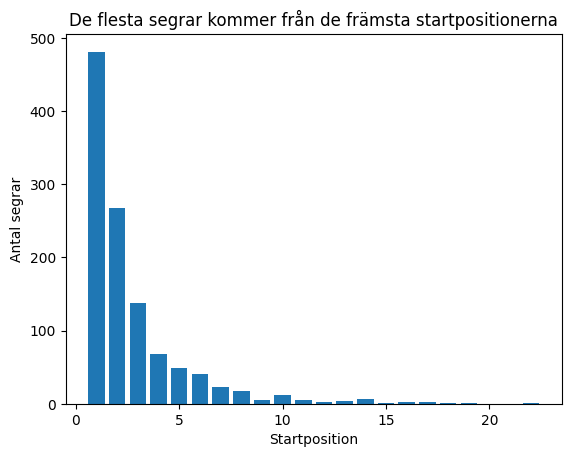

In [208]:
# Filtrera alla vinnare
wins = results[results["positionOrder"] == 1]

# Räkna antal segrar per startposition
wins_per_grid = wins.groupby("grid").size()

# Stapeldiagram
plt.bar(wins_per_grid.index, wins_per_grid.values)

# Titel och axelrubriker
plt.title("De flesta segrar kommer från de främsta startpositionerna")
plt.xlabel("Startposition")
plt.ylabel("Antal segrar")

# Visa grafen
plt.show()

Enligt stapeldiagrammet kommer flest segrar från pole position (först).

Antal segrar minskar tydligt ju längre bak man startar som förare. 

Slutsatsen är att det är betydligt enklare att vinna loppet om man startar längst fram.

## Visualisering 3: Startpositionen har stor betydelse

In [209]:
# Räknar ut hur många placeringar föraren vann eller förlorade under loppet
results["positions_gained"] = results["grid"] - results["positionOrder"]

In [210]:
# Räknar genomsnittlig positionsförändring för varje startposition
average_positions_gained = results.groupby("grid")["positions_gained"].mean()

# Visa resultatet
average_positions_gained

grid
0    -27.139805
1     -4.663732
2     -4.611556
3     -4.505310
4     -4.231449
5     -4.136042
6     -3.574222
7     -3.066960
8     -2.688220
9     -1.803887
10    -1.712389
11    -1.037986
12    -0.102928
13     0.245333
14     0.728571
15     1.485175
16     2.341818
17     2.756657
18     3.206667
19     4.162949
20     4.791795
21     5.055954
22     6.219512
23     6.752759
24     7.265734
25     8.754153
26     9.068548
27     7.326087
28     8.566667
29     7.760000
30     7.210526
31    11.944444
32    15.470588
33    13.538462
34    12.000000
Name: positions_gained, dtype: float64

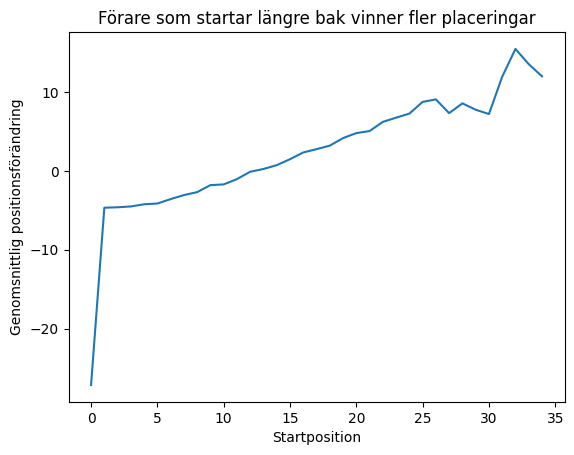

In [ ]:
# Linjediagram
plt.plot(
    average_positions_gained.index,
    average_positions_gained.values
)

# Titel och axelrubriker
plt.title("Förare som startar längre bak vinner fler placeringar")
plt.xlabel("Startposition")
plt.ylabel("Genomsnittlig positionsförändring")

# Visar diagram
plt.show()

I grafen ser vi att förare som startar lägre bak ofta förbättrar sin position i genomsnitt under loppet, medan förare som börjar längre fram tappar.

Logiken är att eftersom förare längre bak har större chans att avancera, medan förare i toppen redan startar högt.

## Avslutning 
Denna analysen siktar sig in på hur startpositioner påverkar resultatet i Formel 1.

Tydligaste mönstret jag upptäckte var att förare som startar bland dem längst fram i genomsnitt får flest poäng och står för flest segrar. Pole position blev den startpositionen som historiskt sett gett bäst resultat.

Förare som startar längre bak förbättrar sin position under loppet, även om detta är sant lyckas de sällan nå samma slutresultat som förare som startar längre fram.

Samtidigt finns det faktorer som denna analys inte tar hänsyn till. Så en fråga som blev obesvarad är hur stor del av resultatet som faktiskt beror på startpositionen och hur stor del beror på andra faktorer, ex skicklighet på föraren, bilens prestanda och strategin teamet planerat.

Datan förklarar inte iheller varför en förare lyckas förbättra eller tappa placering. Faktorer som inte finns med i datasetet är bland annat väder, säkerhetsbilar, depåstopp, däck eller tekniska problem.

Analysen omfattar endast resultatet, inte allt som händer under loppet.

För att sammanfatta så visar analysen att ja, startpositionen har stor betydelse och datan visar faktiskt att bättre position ger i genomsnitt bättre reslutat och att det har betydelse, men den kan inte förklara varför ett lopp slutar som det gör. 
